# Classify Loop 3 Data with Loop 2 Classifier.

## Prepare Notebook.

### Import Libraries.

In [22]:
import yaml

import numpy as np
import scanpy as sc
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

import sc_exp_design

### Read Configurations.

In [8]:
annot_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(annot_path, "r") as fb:
    annot_dict = yaml.safe_load(fb)
scatter_cols = annot_dict["scatter_columns"]

## Load Loop 3 Data.

### Read Data from Disk.

In [2]:
h5ad_loop3_res_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k_residual.h5ad"
adata_res_loop3 = sc.read_h5ad(h5ad_loop3_res_path)
adata_res_loop3

AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Compute Neighbors Graph and UMAP for Loop 2 Data.

In [25]:
sc.pp.neighbors(adata_res_loop3)
sc.tl.umap(adata_res_loop3)
adata_res_loop3


AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap'
 

### Prepare Features.

In [9]:
X_channel = adata_res_loop3.X
X_scatter = adata_res_loop3.obs[scatter_cols].astype(float).values

## Load Loop 2 Classifier.

### Load Model.

In [4]:
clf_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/loop2_replicate/2026-06-25_12-41-22/robust-terrain-39_TargetPredictionModel.pkl"
clf = sc_exp_design.models.TargetPredictionModel.load(clf_path)
clf

### Retrieve Standardization Parameters.

In [5]:
train_adata = clf.train_data.adata
scatter_params = train_adata.uns["X_scatter_params"]
channel_params = train_adata.uns["X_channel_params"]

### Standardize Features.

In [12]:
X_channel_transf = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter_transf = (X_scatter - scatter_params["mean"])/scatter_params["std"]
X_tranf = np.concatenate((X_channel_transf, X_scatter_transf), axis=1)

### Fit Label Encoder.

In [23]:
ct_le = LabelEncoder()
ct_values = train_adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())


## Classify Data.

### Prepare Dataloader.

In [15]:
X_torch = torch.from_numpy(X_tranf).to(torch.float32).to(clf.device)
dataset = TensorDataset(X_torch)
dataloader = DataLoader(dataset, batch_size=10_000, shuffle=False)


### Classify.

In [24]:
# ---- List to store the predictions ----
ct_preds = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader):
        xb = xb[0]
        y_pred = clf.predict(xb)["cell_type_reannot_final"].argmax(1)
        ct_preds.append(y_pred.cpu().detach().numpy())
ct_preds = np.concatenate(ct_preds)

# ---- Decode predicted cell types ----
ct_preds = classes[ct_preds]

# ---- Write back to anndata ----
adata_res_loop3.obs["cell_type"] = ct_preds
adata_res_loop3

100%|██████████| 50/50 [00:03<00:00, 15.99it/s]


AnnData object with n_obs × n_vars = 499996 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives

### Visualize Predictions.

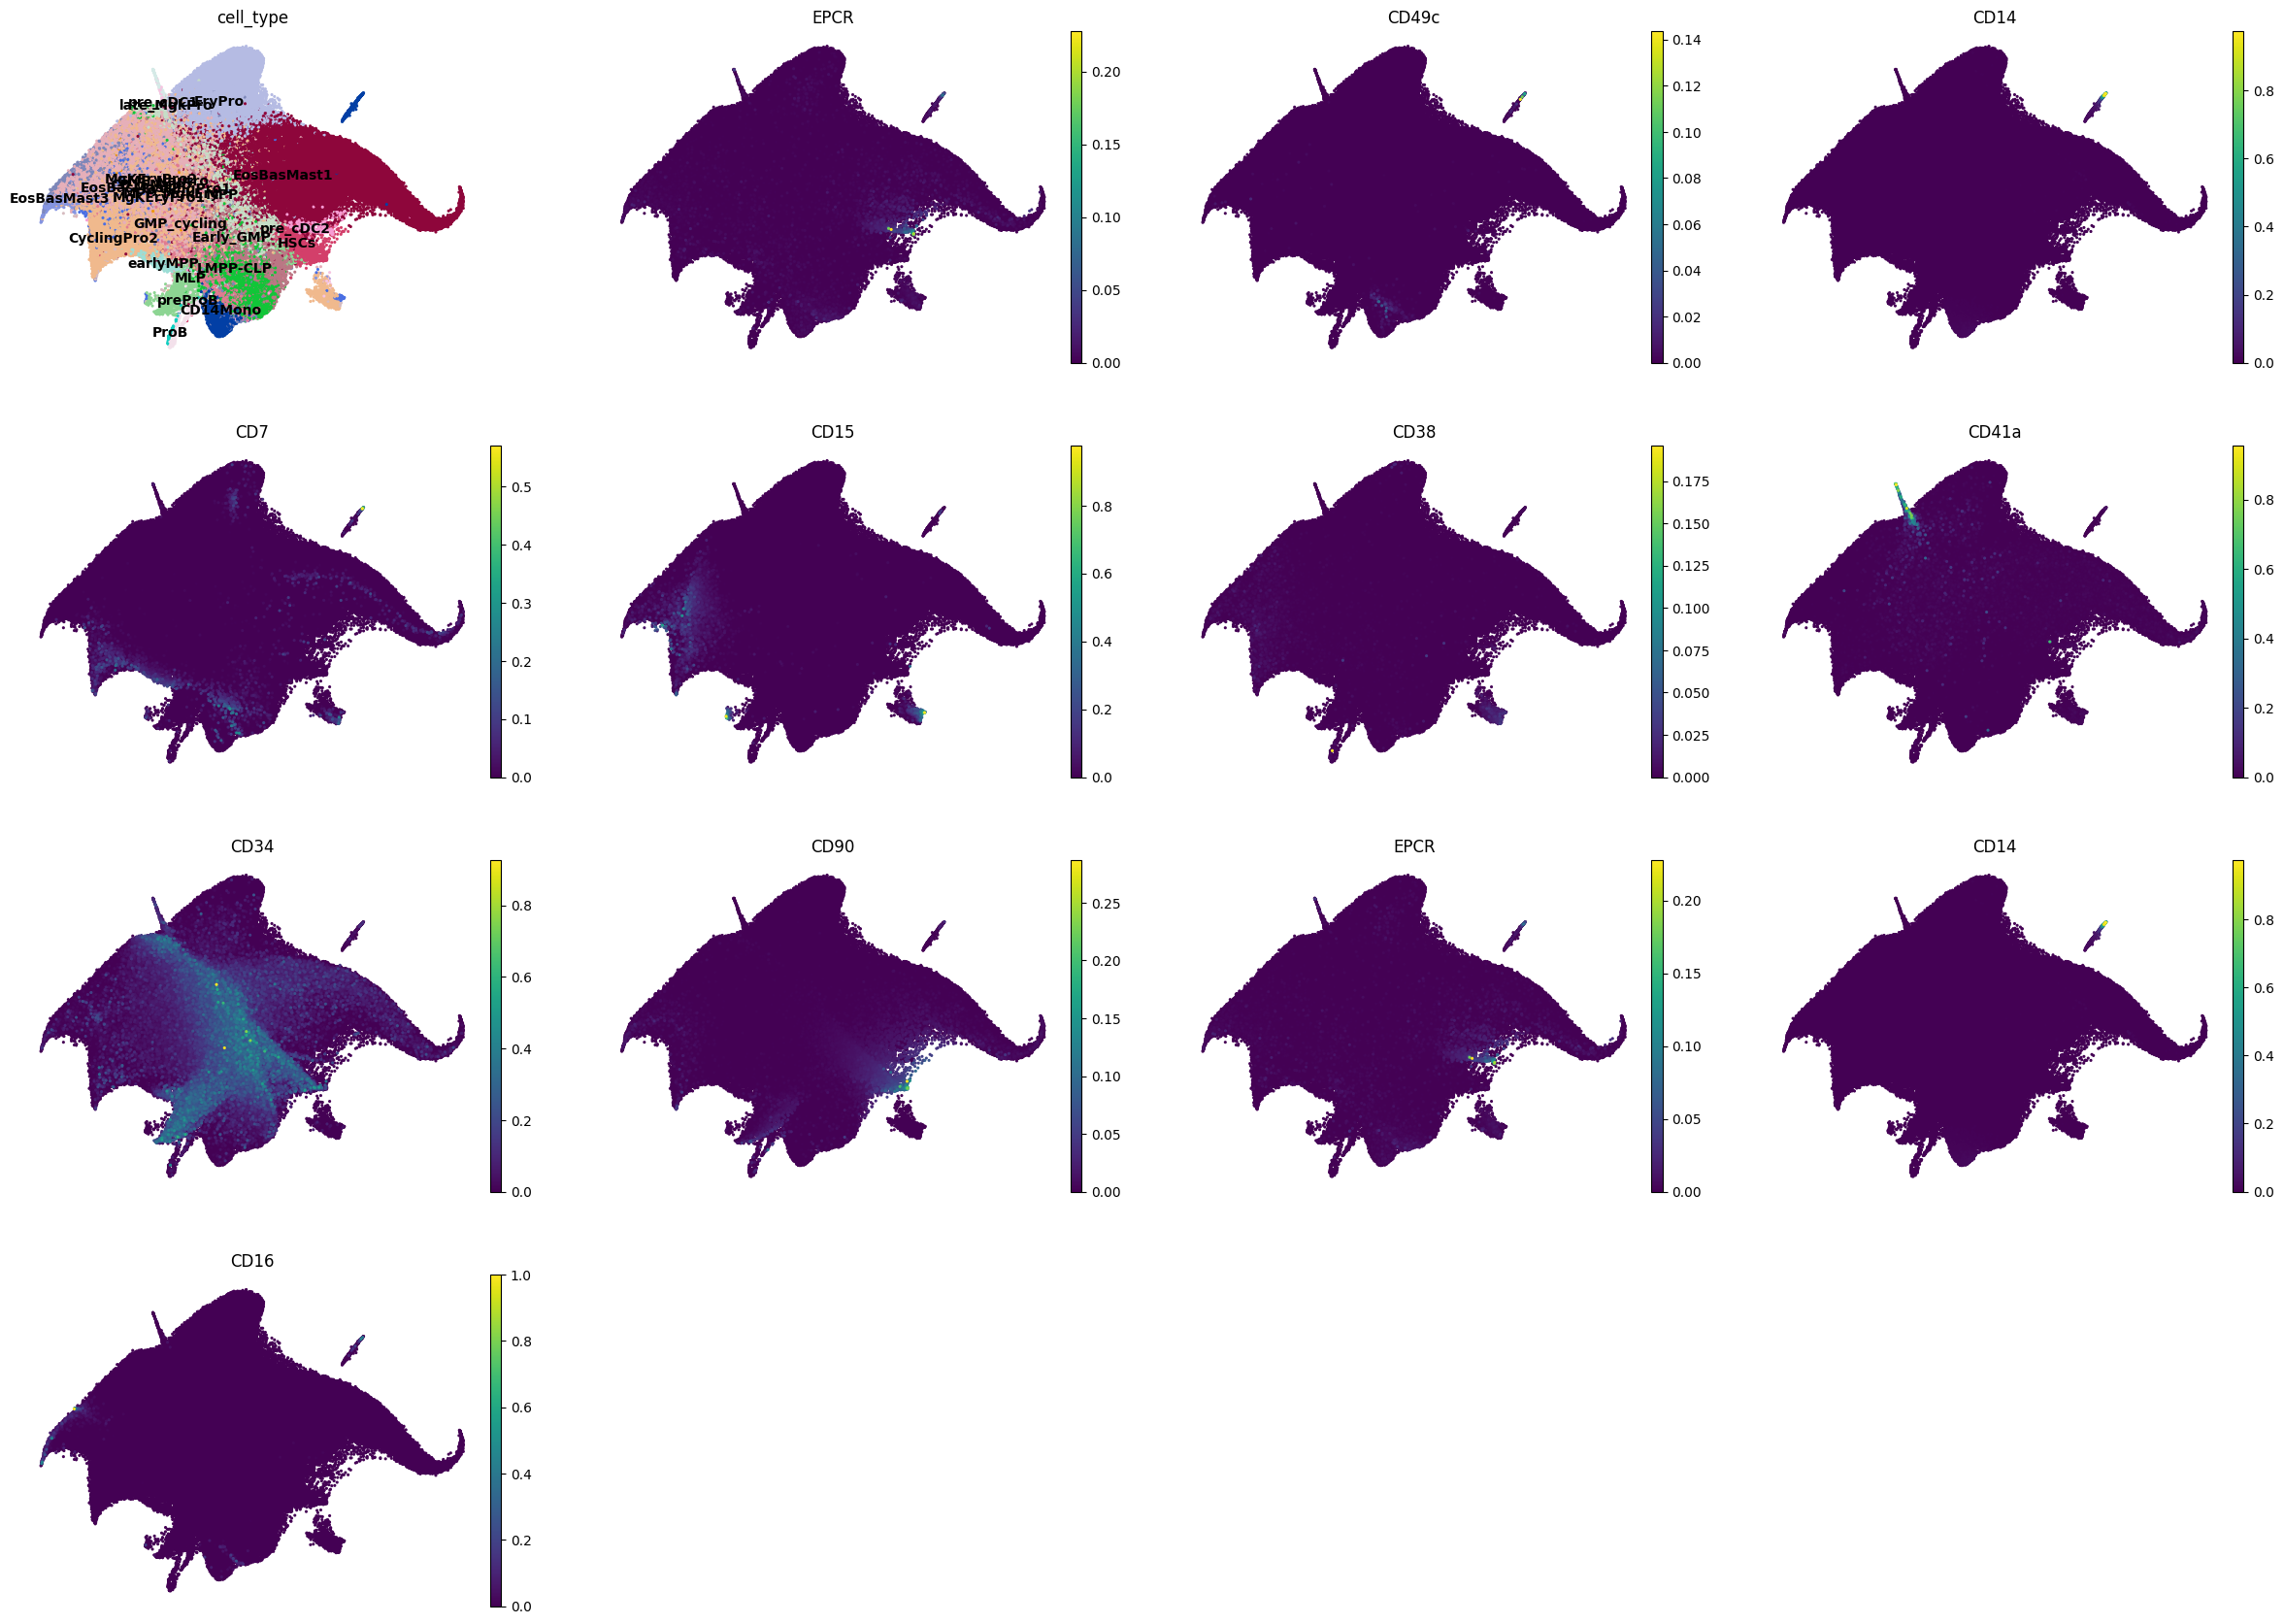

In [26]:
dc1_markers = ["EPCR", "CD49c", "CD14", "CD7", "CD15", "CD38"]
mgk_markers = ["CD41a"]
hsc_markers = ["CD34", "CD90", "EPCR"]
cd14_markers = ["CD14"]
cd16_markers = ["CD16"]

sc.pl.embedding(adata_res_loop3, "umap", color=["cell_type"] + dc1_markers + mgk_markers + hsc_markers + cd14_markers + cd16_markers, frameon=False, legend_loc="on data", s=20)


### Plot each Cell Type Individually


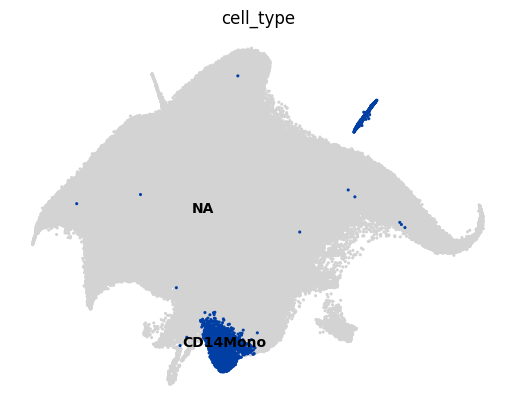

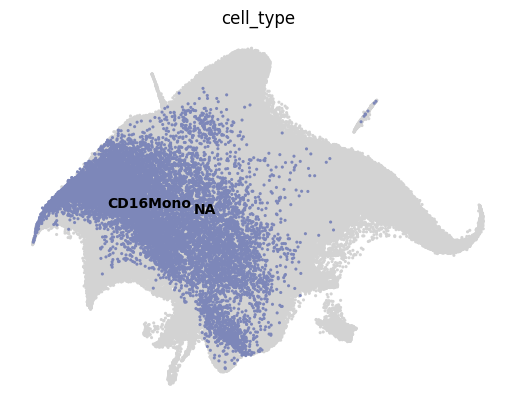

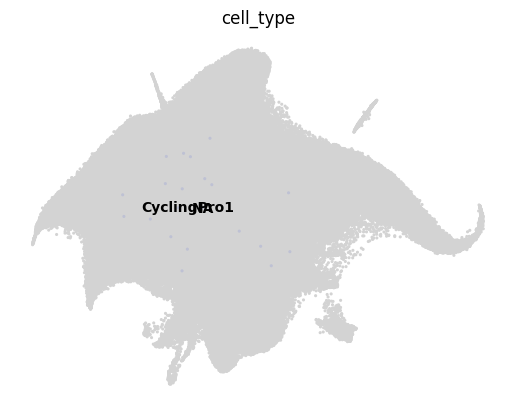

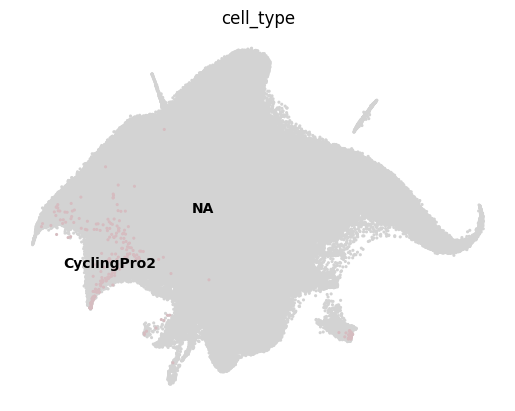

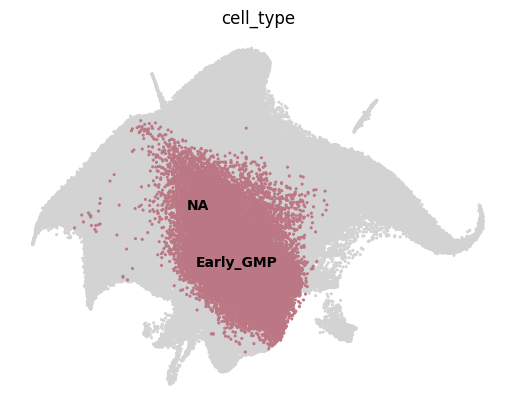

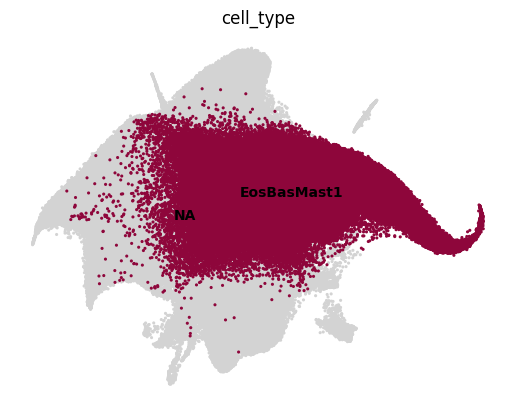

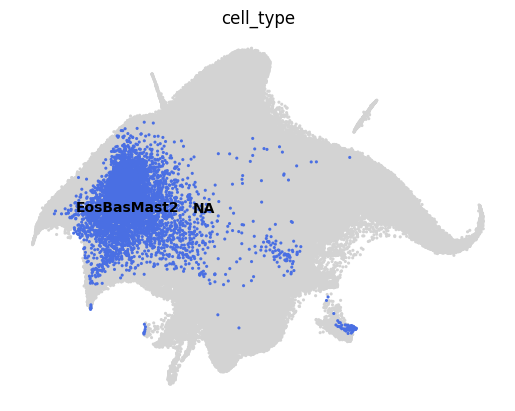

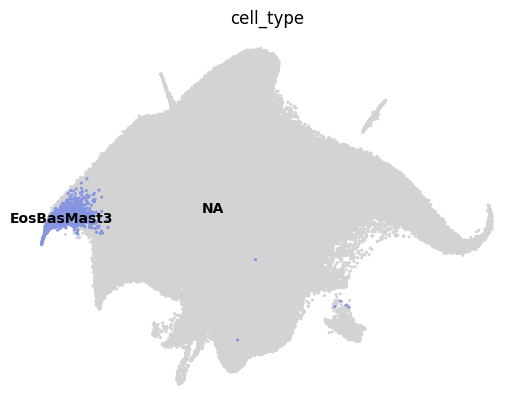

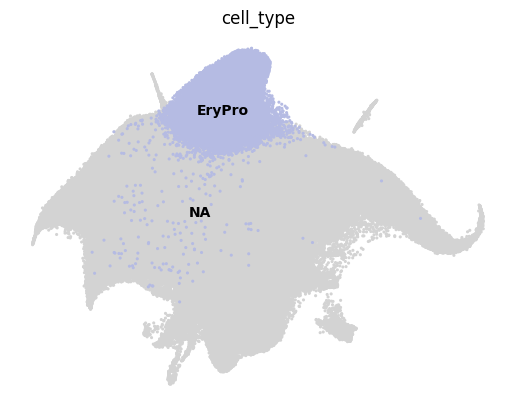

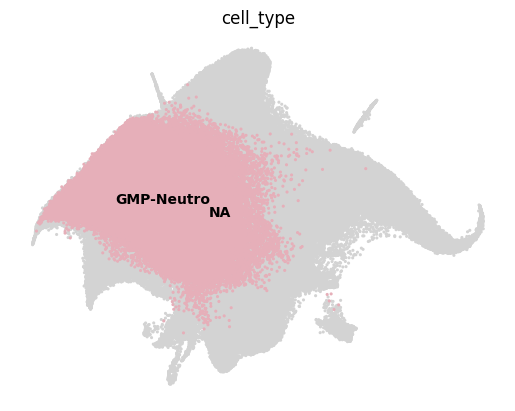

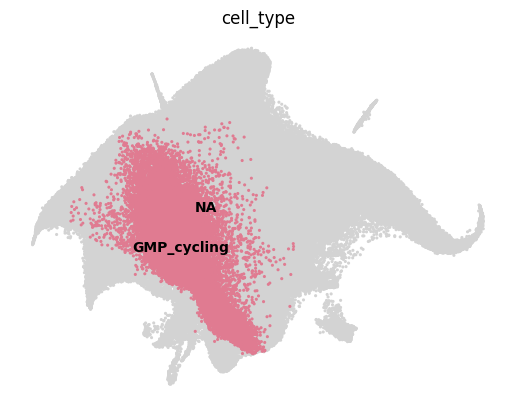

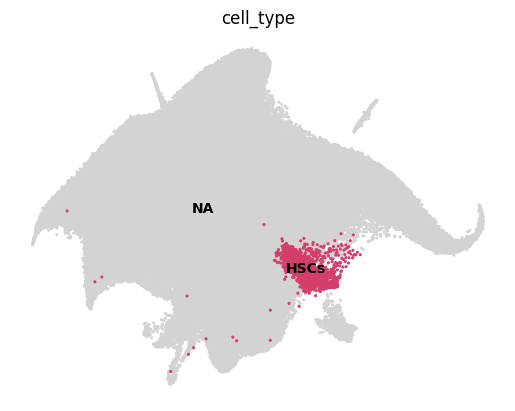

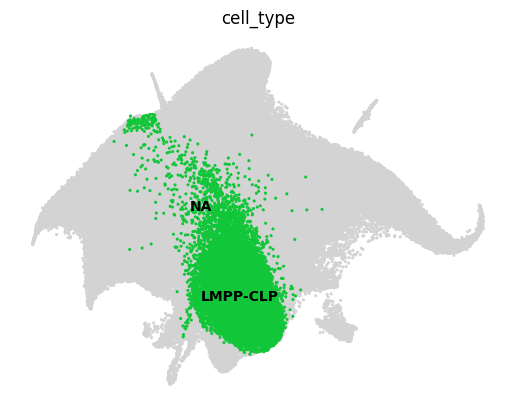

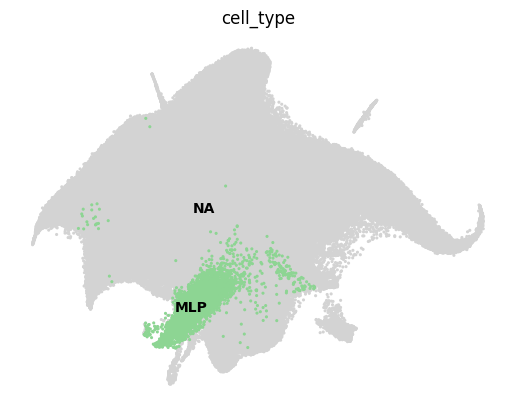

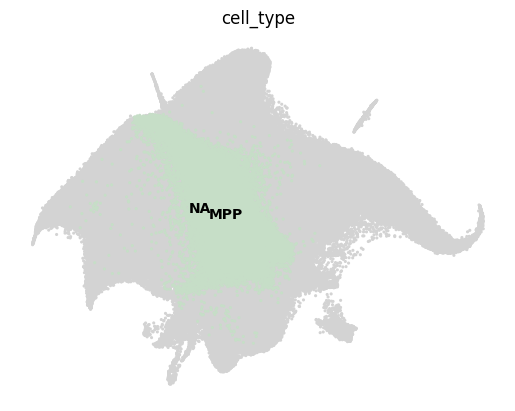

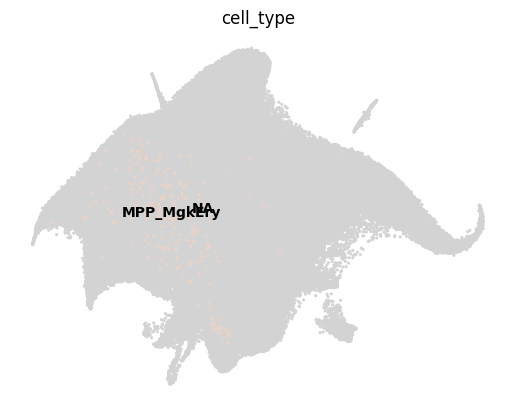

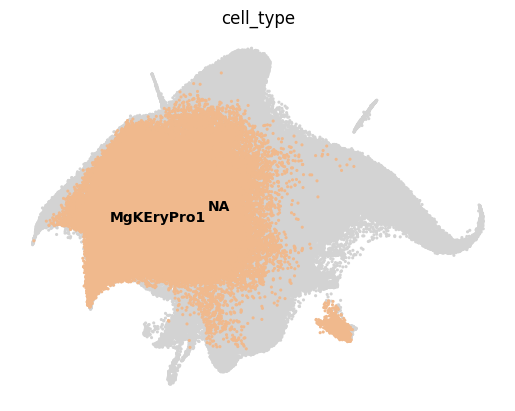

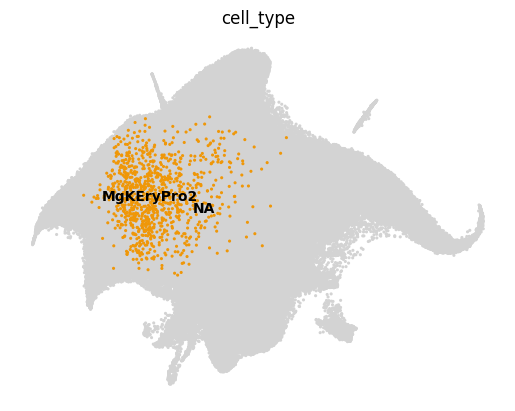

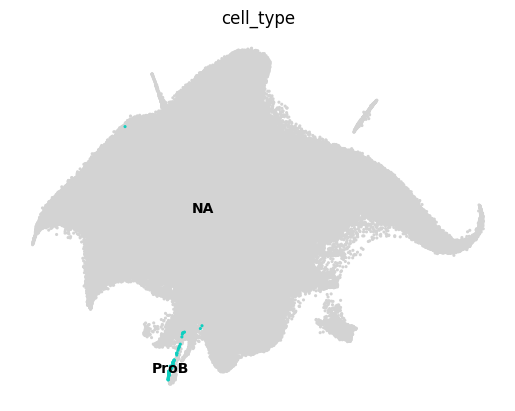

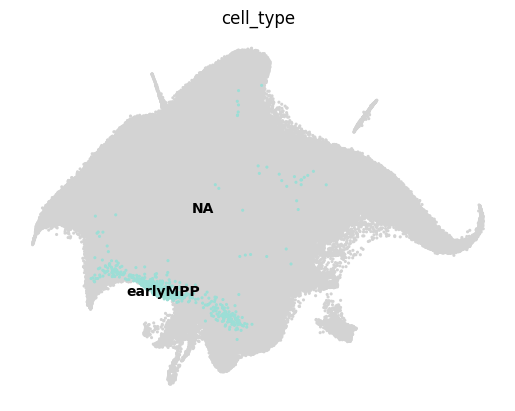

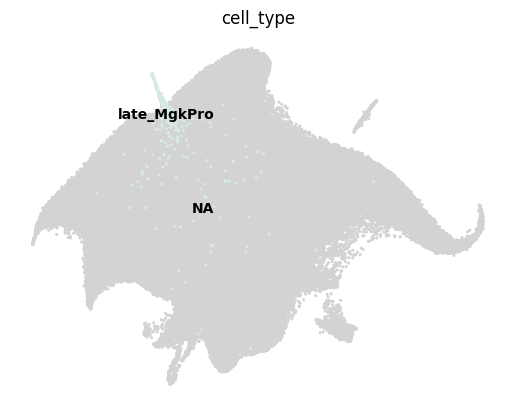

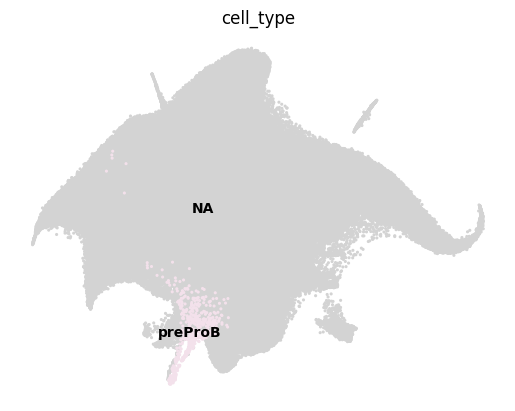

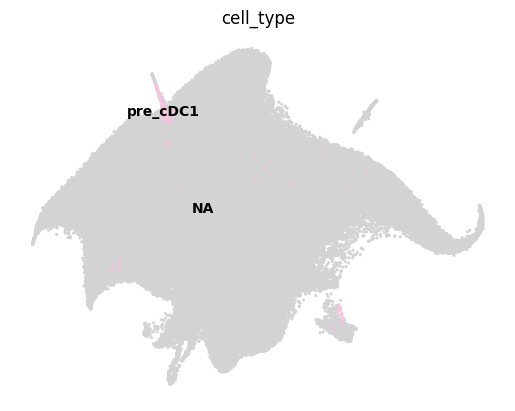

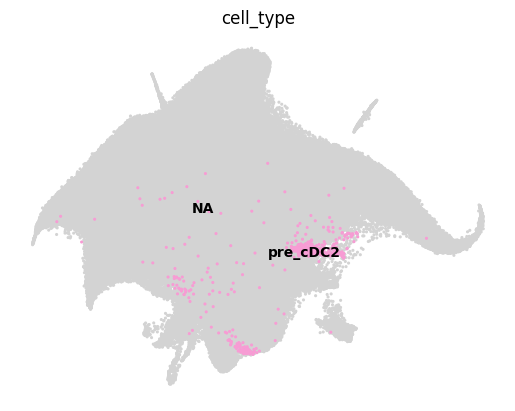

In [27]:
for ct in classes:
    sc.pl.embedding(adata_res_loop3, "umap", color=["cell_type"], groups=[ct], frameon=False, legend_loc="on data", s=20)
